## MNIST Variational Encoder Decoder

In [10]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Lambda, Layer
from tensorflow.keras.models import Model
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras import backend as K
import numpy as np

In [24]:
# Hyperparameters
input_dim = 784  # 28x28 pixels, flattened
latent_dim = 2   # Dimensionality of the latent space
intermediate_dim = 512
batch_size = 100
epochs = 50

In [25]:
# Load and preprocess the MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((x_train.shape[0], input_dim))
x_test = x_test.reshape((x_test.shape[0], input_dim))

In [26]:
# Custom sampling layer for VAE
class SamplingLayer(Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + K.exp(0.5 * z_log_var) * epsilon

In [27]:
# Encoder
inputs = Input(shape=(input_dim,))
h = Dense(intermediate_dim, activation='relu')(inputs)
z_mean = Dense(latent_dim)(h)
z_log_var = Dense(latent_dim)(h)

In [28]:
# Custom sampling
z = SamplingLayer()([z_mean, z_log_var])

In [29]:
# Decoder
decoder_h = Dense(intermediate_dim, activation='relu')
decoder_mean = Dense(input_dim, activation='sigmoid')
h_decoded = decoder_h(z)
x_decoded_mean = decoder_mean(h_decoded)

In [30]:
# VAE model
vae = Model(inputs, x_decoded_mean)

In [31]:
# Custom VAE loss layer
class VAELossLayer(Layer):
    def call(self, inputs):
        x, x_decoded_mean, z_mean, z_log_var = inputs
        reconstruction_loss = binary_crossentropy(x, x_decoded_mean)
        reconstruction_loss *= input_dim
        kl_loss = 1 + z_log_var - K.square(z_mean) - K.exp(z_log_var)
        kl_loss = K.sum(kl_loss, axis=-1)
        kl_loss *= -0.5
        vae_loss = K.mean(reconstruction_loss + kl_loss)
        self.add_loss(vae_loss)
        return x_decoded_mean


In [32]:
# Add the custom loss layer to the model
output_with_loss = VAELossLayer()([inputs, x_decoded_mean, z_mean, z_log_var])

# Update the VAE model to include the custom loss
vae = Model(inputs, output_with_loss)

vae.compile(optimizer='rmsprop')

# Train the VAE
vae.fit(x_train, x_train,
        shuffle=True,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_test, x_test))

# Encoder model to project inputs on the latent space
encoder = Model(inputs, z_mean)

Epoch 1/50
600/600 [==============================] - 3s 5ms/step - loss: 186.7709 - val_loss: 172.9097
Epoch 2/50
600/600 [==============================] - 3s 5ms/step - loss: 170.6523 - val_loss: 168.6364
Epoch 3/50
600/600 [==============================] - 3s 5ms/step - loss: 166.7870 - val_loss: 165.4307
Epoch 4/50
600/600 [==============================] - 3s 5ms/step - loss: 164.4526 - val_loss: 163.3610
Epoch 5/50
600/600 [==============================] - 3s 5ms/step - loss: 162.9875 - val_loss: 162.6865
Epoch 6/50
600/600 [==============================] - 3s 5ms/step - loss: 161.8632 - val_loss: 161.2834
Epoch 7/50
600/600 [==============================] - 3s 5ms/step - loss: 161.0090 - val_loss: 160.9515
Epoch 8/50
600/600 [==============================] - 3s 5ms/step - loss: 160.2037 - val_loss: 159.9641
Epoch 9/50
600/600 [==============================] - 3s 5ms/step - loss: 159.5183 - val_loss: 159.4789
Epoch 10/50
600/600 [==============================] - 3s 5ms/st

In [33]:
# Generator model to generate new data points from latent space
decoder_input = Input(shape=(latent_dim,))
_h_decoded = decoder_h(decoder_input)
_x_decoded_mean = decoder_mean(_h_decoded)
generator = Model(decoder_input, _x_decoded_mean)

1/1 [==============================] - 0s 48ms/step


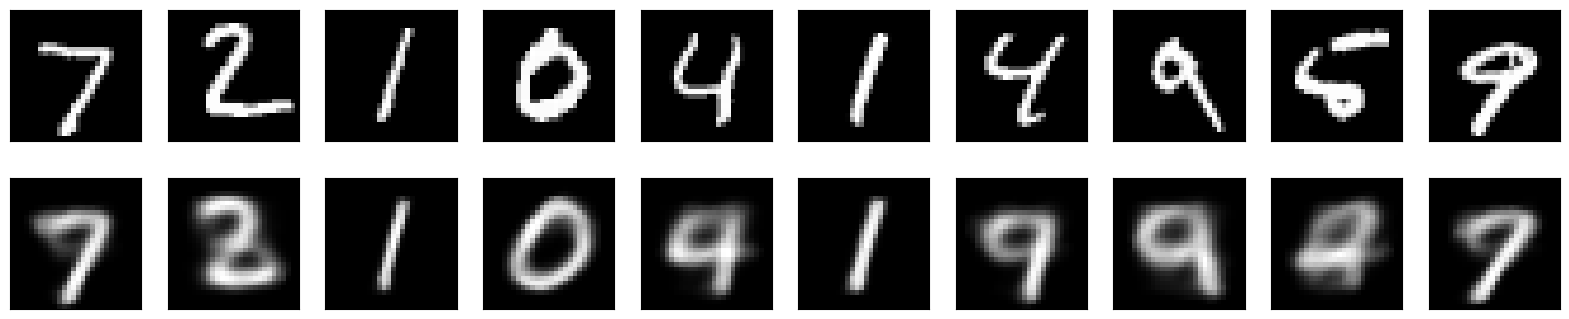

In [34]:
# Example usage: Visualize some encoded and decoded images
import matplotlib.pyplot as plt

# Encode and decode some digits from the test set
encoded_imgs = encoder.predict(x_test[:10])
decoded_imgs = vae.predict(x_test[:10])

# Plot original and reconstructed images
n = 10  # Number of digits to display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Reconstructed images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()